# Capitolo 7 — Diagnosticare un cuscinetto dalla vibrazione (CWRU)
Segnali e spettri, finestre, tre rappresentazioni (caratteristiche / spettro / segnale grezzo), filtri appresi, cambio di carico. Circa 2 minuti più il download (35 + 75 MB).

In [1]:
import sys; sys.path.insert(0, "..")
from utils import fissa_seme
import dati
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
fissa_seme(42)

from scipy import signal as sg
FS, L, PASSO = dati.CWRU_FS, 1024, 512
CLASSI, NOMI = dati.CWRU_CLASSI, dati.CWRU_NOMI
seg0 = dati.cuscinetti(0)
X_tr, y_tr = dati.finestre_cuscinetti(seg0, 0, 0.7); X_va, y_va = dati.finestre_cuscinetti(seg0, 0.7, 0.85); X_te, y_te = dati.finestre_cuscinetti(seg0, 0.85, 1.0)
Xn_tr, Xn_va, Xn_te = map(dati.normalizza_finestre, (X_tr, X_va, X_te))
print("finestre:", X_tr.shape, X_va.shape, X_te.shape)

finestre: (1711, 1024) (353, 1024) (353, 1024)


## Segnali e spettri (§ 7.2)

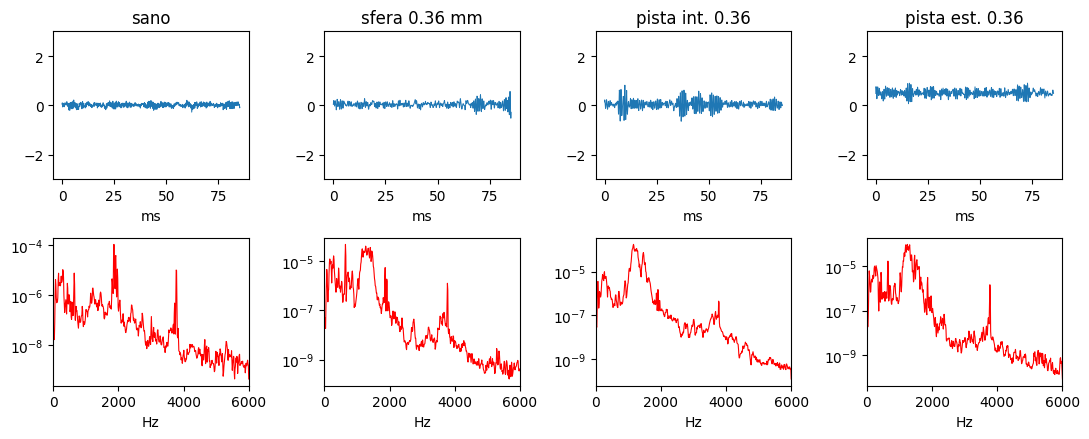

In [2]:
fig, ax = plt.subplots(2, 4, figsize=(11, 4.5))
for j, c in enumerate(["NORMAL", "B014", "IR014", "OR0146"]):
    s = seg0[c][:L]; ax[0, j].plot(np.arange(L) / FS * 1000, s, lw=0.7); ax[0, j].set_title(NOMI[c]); ax[0, j].set_xlabel("ms"); ax[0, j].set_ylim(-3, 3)
    f, P = sg.welch(seg0[c][:FS * 2], FS, nperseg=1024); ax[1, j].semilogy(f, P, lw=0.8, color="red"); ax[1, j].set_xlabel("Hz"); ax[1, j].set_xlim(0, 6000)
plt.tight_layout(); plt.show()

## Tre rappresentazioni (§ 7.4)

In [3]:
def caratteristiche(X):
    rms = np.sqrt((X ** 2).mean(1)); picco = np.abs(X).max(1); Xc = X - X.mean(1, keepdims=True)
    curtosi = (Xc ** 4).mean(1) / (X.var(1) ** 2 + 1e-12); asimm = (Xc ** 3).mean(1) / (X.std(1) ** 3 + 1e-12); cresta = picco / (rms + 1e-8)
    F = np.abs(np.fft.rfft(X, axis=1))[:, :L // 2]; fr = np.fft.rfftfreq(L, 1 / FS)[:L // 2]
    baric = (F * fr).sum(1) / (F.sum(1) + 1e-8); larg = np.sqrt((F * (fr - baric[:, None]) ** 2).sum(1) / (F.sum(1) + 1e-8))
    return np.stack([rms, picco, curtosi, asimm, cresta, baric, larg], 1)
def spettro(X): return np.log1p(np.abs(np.fft.rfft(X, axis=1))[:, :L // 2])
def normalizza_colonne(tr, *altri):
    m, s = tr.mean(0), tr.std(0) + 1e-8; return [((a - m) / s).astype(np.float32) for a in (tr,) + altri]
F_tr, F_va, F_te = normalizza_colonne(caratteristiche(X_tr), caratteristiche(X_va), caratteristiche(X_te))
S_tr, S_va, S_te = normalizza_colonne(spettro(X_tr), spettro(X_va), spettro(X_te))
spettro_media, spettro_dev = spettro(X_tr).mean(0), spettro(X_tr).std(0) + 1e-8      # servono per il cambio di carico

In [4]:
class CNN1D(nn.Module):
    def __init__(self, classi=10):
        super().__init__()
        def blocco(i, o, k, stride=1): return nn.Sequential(nn.Conv1d(i, o, k, stride=stride, padding=k // 2), nn.BatchNorm1d(o), nn.ReLU())
        self.conv = nn.Sequential(blocco(1, 16, 64, stride=8), nn.MaxPool1d(2), blocco(16, 32, 3), nn.MaxPool1d(2), blocco(32, 64, 3), nn.MaxPool1d(2), blocco(64, 64, 3), nn.AdaptiveAvgPool1d(1))
        self.fc = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(64, classi))
    def forward(self, x): return self.fc(self.conv(x))
def mlp(d): return nn.Sequential(nn.Linear(d, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 10))

def addestra(m, Xtr, ytr, Xva, yva, epoche=30, bs=64):
    Xtr, Xva = torch.from_numpy(Xtr).float(), torch.from_numpy(Xva).float(); ytr, yva = torch.from_numpy(ytr), torch.from_numpy(yva)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4); fn = nn.CrossEntropyLoss(); migliore = (0, None, 0)
    for epoca in range(epoche):
        m.train(); perm = torch.randperm(len(Xtr))
        for i in range(0, len(Xtr), bs):
            idx = perm[i:i + bs]; opt.zero_grad(); fn(m(Xtr[idx]), ytr[idx]).backward(); opt.step()
        m.eval()
        with torch.no_grad(): av = (m(Xva).argmax(1) == yva).float().mean().item()
        if av > migliore[0]: migliore = (av, {k: v.clone() for k, v in m.state_dict().items()}, epoca + 1)
    m.load_state_dict(migliore[1]); return migliore
def accuratezza(m, X, y):
    m.eval()
    with torch.no_grad(): return float((m(torch.from_numpy(X).float()).argmax(1).numpy() == y).mean())

fissa_seme(42); m_feat = mlp(7); mig = addestra(m_feat, F_tr, y_tr, F_va, y_va, epoche=60); print(f"7 caratteristiche + MLP: val {mig[0]:.1%} (ep {mig[2]})  test {accuratezza(m_feat, F_te, y_te):.1%}")
fissa_seme(42); m_fft = mlp(L // 2); mig = addestra(m_fft, S_tr, y_tr, S_va, y_va, epoche=40); print(f"spettro + MLP:           val {mig[0]:.1%} (ep {mig[2]})  test {accuratezza(m_fft, S_te, y_te):.1%}")
fissa_seme(42); m_cnn = CNN1D(); mig = addestra(m_cnn, Xn_tr[:, None, :], y_tr, Xn_va[:, None, :], y_va, epoche=30); print(f"segnale grezzo + CNN 1D: val {mig[0]:.1%} (ep {mig[2]})  test {accuratezza(m_cnn, Xn_te[:, None, :], y_te):.1%}")
torch.save(m_cnn.state_dict(), "cwru_cnn.pt"); torch.save(m_fft.state_dict(), "cwru_fft.pt")

7 caratteristiche + MLP: val 99.4% (ep 48)  test 96.9%


spettro + MLP:           val 100.0% (ep 3)  test 99.7%


segnale grezzo + CNN 1D: val 100.0% (ep 27)  test 100.0%


## I filtri del primo strato sono passa-banda (§ 7.5)

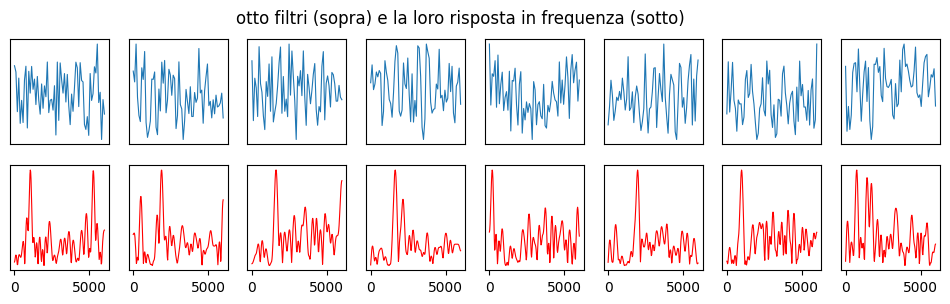

In [5]:
W = m_cnn.conv[0][0].weight.detach().numpy()[:, 0, :]
fig, ax = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    ax[0, i].plot(W[i], lw=0.8); ax[0, i].set_xticks([]); ax[0, i].set_yticks([])
    ax[1, i].plot(np.fft.rfftfreq(512, 1 / FS), np.abs(np.fft.rfft(W[i], 512)), lw=0.8, color="red"); ax[1, i].set_yticks([])
plt.suptitle("otto filtri (sopra) e la loro risposta in frequenza (sotto)"); plt.show()

## Il cambio di carico: 0 HP → 1 HP (§ 7.6)

CNN 1D a 1 HP: 89.2%    spettro + MLP a 1 HP: 78.1%   (5153 finestre)


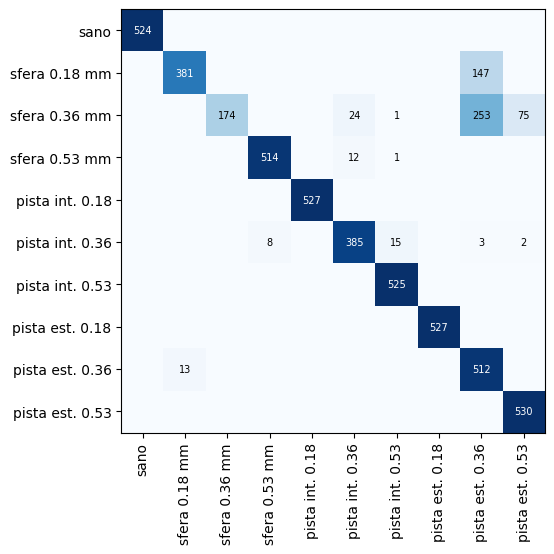

In [6]:
seg1 = dati.cuscinetti(1); X1, y1 = dati.finestre_cuscinetti(seg1, 0, 1.0); X1n = dati.normalizza_finestre(X1)
S1 = ((spettro(X1) - spettro_media) / spettro_dev).astype(np.float32)
print(f"CNN 1D a 1 HP: {accuratezza(m_cnn, X1n[:, None, :], y1):.1%}    spettro + MLP a 1 HP: {accuratezza(m_fft, S1, y1):.1%}   ({len(y1)} finestre)")
from sklearn.metrics import confusion_matrix
m_cnn.eval()
with torch.no_grad(): p1 = m_cnn(torch.from_numpy(X1n[:, None, :]).float()).argmax(1).numpy()
C = confusion_matrix(y1, p1)
fig, ax = plt.subplots(figsize=(6, 5.5)); ax.imshow(C / C.sum(1, keepdims=True), cmap="Blues")
for i in range(10):
    for j in range(10):
        if C[i, j] > 0: ax.text(j, i, C[i, j], ha="center", va="center", fontsize=7, color="white" if C[i, j] > C[i].sum() / 2 else "black")
ax.set_xticks(range(10)); ax.set_yticks(range(10)); ax.set_xticklabels([NOMI[c] for c in CLASSI], rotation=90); ax.set_yticklabels([NOMI[c] for c in CLASSI]); plt.show()